In [ ]:
# Install deps
!pip install -q pandas scikit-learn matplotlib seaborn numpy

import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштовуємо робочу директорію та клонуємо репозиторій
os.chdir('/content')
!rm -rf NLP_Course
REPO_URL = "https://github.com/dmytroslav/NLP_Course.git"
!git clone $REPO_URL
sys.path.append('/content/NLP_Course/src')

# Data access
data_path = '/content/NLP_Course/data/processed_v2.csv'
try:
    df = pd.read_csv(data_path).dropna(subset=['text'])
    print(f"Завантажено {len(df)} текстів з processed_v2.csv.")
except FileNotFoundError:
    print(f"Файл {data_path} не знайдено.")

Cloning into 'NLP_Course'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 135 (delta 49), reused 112 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 1.97 MiB | 11.66 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Завантажено 10735 текстів з processed_v2.csv.


In [ ]:
# Load split
def load_split_by_ids(df, split_name):
    ids_path = f'/content/NLP_Course/data/sample/splits_{split_name}_ids.txt'
    with open(ids_path, 'r') as f:
        ids = [int(line.strip()) for line in f.readlines() if line.strip()]
    return df.loc[ids].copy()

train_df = load_split_by_ids(df, 'train')
val_df = load_split_by_ids(df, 'val')
test_df = load_split_by_ids(df, 'test')

X_train, y_train = train_df['text'], train_df['label']
X_val, y_val = val_df['text'], val_df['label']
X_test, y_test = test_df['text'], test_df['label']

print(f"Розміри сплітів завантажено: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

Розміри сплітів завантажено: Train=8587, Val=1074, Test=1074


In [ ]:
import classification_baseline
importlib.reload(classification_baseline)

# Baseline 1
# TF-IDF word(1,1) + Logistic Regression (базова)
print("=== Тренування Baseline 1 (unigrams, no class_weight) ===")
pipe_b1 = classification_baseline.build_pipeline(ngram_range=(1, 1), class_weight=None)
pipe_b1.fit(X_train, y_train)

res_b1_val = classification_baseline.evaluate_model(pipe_b1, X_val, y_val)
res_b1_test = classification_baseline.evaluate_model(pipe_b1, X_test, y_test)

# Baseline 2
# TF-IDF word(1,2) + Logistic Regression (class_weight='balanced')
print("=== Тренування Baseline 2 (bigrams, class_weight='balanced') ===")
pipe_b2 = classification_baseline.build_pipeline(ngram_range=(1, 2), class_weight='balanced')
pipe_b2.fit(X_train, y_train)

res_b2_val = classification_baseline.evaluate_model(pipe_b2, X_val, y_val)
res_b2_test = classification_baseline.evaluate_model(pipe_b2, X_test, y_test)

# Metrics comparison
print("\n=== Порівняння метрик на TEST ===")
print(f"Baseline 1: Accuracy = {res_b1_test['accuracy']:.4f}, Macro-F1 = {res_b1_test['macro_f1']:.4f}")
print(f"Baseline 2: Accuracy = {res_b2_test['accuracy']:.4f}, Macro-F1 = {res_b2_test['macro_f1']:.4f}")

# Baseline 2 report
print("\nClassification Report (Baseline 2 - Test):")
print(res_b2_test['report'])

=== Тренування Baseline 1 (unigrams, no class_weight) ===
=== Тренування Baseline 2 (bigrams, class_weight='balanced') ===

=== Порівняння метрик на TEST ===
Baseline 1: Accuracy = 0.8911, Macro-F1 = 0.8185
Baseline 2: Accuracy = 0.8939, Macro-F1 = 0.8510

Classification Report (Baseline 2 - Test):
              precision    recall  f1-score   support

       False       0.77      0.77      0.77       250
        True       0.93      0.93      0.93       824

    accuracy                           0.89      1074
   macro avg       0.85      0.85      0.85      1074
weighted avg       0.89      0.89      0.89      1074



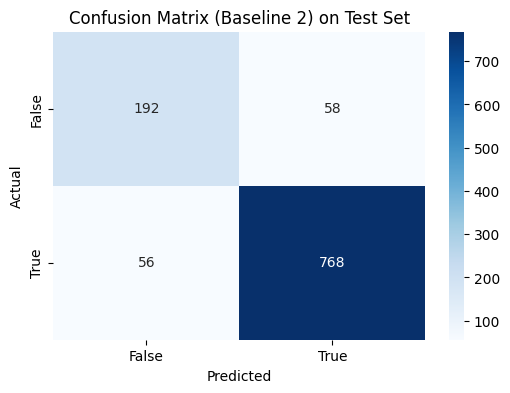


=== Топ-15 фіч для класу FALSE (негативні ваги) ===
телеграм             -7.7504
про це               -7.6211
це                   -6.9254
відео                -4.7736
українські           -4.6492
канали               -4.2837
повідомлення         -3.8180
змі                  -3.7133
про                  -3.7066
фото                 -3.6870
каналах              -3.5642
такі                 -3.5610
телеграм канали      -3.5566
російські            -3.4794
лавров               -3.3115

=== Топ-15 фіч для класу TRUE (позитивні ваги) ===
окупанти             3.9857
вибухи               2.2798
окупантів            2.0551
війни                1.9391
сьогодні             1.8210
ппо                  1.7274
білорусі             1.6642
повідомляють про     1.6490
єс                   1.5936
рашисти              1.5305
про вибухи           1.5046
ракет                1.4832
до                   1.4305
ще                   1.3148
млрд                 1.3029


In [ ]:
# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(res_b2_test['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.title('Confusion Matrix (Baseline 2) on Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Top features
top_features = classification_baseline.get_top_features(pipe_b2, class_names=['False', 'True'], top_n=15)

print("\n=== Топ-15 фіч для класу FALSE (негативні ваги) ===")
for feat, weight in top_features['False']:
    print(f"{feat:<20} {weight:.4f}")

print("\n=== Топ-15 фіч для класу TRUE (позитивні ваги) ===")
for feat, weight in top_features['True']:
    print(f"{feat:<20} {weight:.4f}")

In [ ]:
# Error analysis
test_df_results = test_df.copy()
test_df_results['predicted'] = res_b2_test['y_pred']

# Фільтруємо помилки: gold label != predicted label
errors = test_df_results[test_df_results['label'] != test_df_results['predicted']]

print(f"Всього помилок на тестовому наборі: {len(errors)} з {len(test_df)}")
print("\n=== 10 прикладів помилок для ручного аналізу ===")

for idx, row in errors.sample(min(10, len(errors)), random_state=42).iterrows():
    print("-" * 80)
    print(f"ID: {idx}")
    print(f"Gold: {row['label']} | Predicted: {row['predicted']}")
    print(f"Текст: {row['text'][:200]}...") # Виводимо перші 200 символів

Всього помилок на тестовому наборі: 114 з 1074

=== 10 прикладів помилок для ручного аналізу ===
--------------------------------------------------------------------------------
ID: 10196
Gold: False | Predicted: True
Текст: ЗСУ завдали успішного удару по російському складу з боєприпасами....
--------------------------------------------------------------------------------
ID: 10546
Gold: False | Predicted: True
Текст: На Кримському мості горить усі полотно автомобільної дороги. Міст ось-ось обрушиться. Кореспонденти ведуть пряму трансляцію із місця подій....
--------------------------------------------------------------------------------
ID: 2148
Gold: True | Predicted: False
Текст: Українські військові показали сухпійки російської армії - вони виявилися простроченими на 7 років...
--------------------------------------------------------------------------------
ID: 22
Gold: True | Predicted: False
Текст: Лукашенко заявив, що Білорусь провела в Україні "спецоперацію" зі звільнення білор

In [ ]:
# Generate docs/audit_summary_lab6.md
os.makedirs('/content/NLP_Course/docs', exist_ok=True)

summary_content = f"""# Audit Summary (Lab 6)

1. **Підзадача**: Бінарна класифікація текстів (True/False).
2. **Split**: Використано збережений Stratified random split (80/10/10) з ЛР5.
3. **Baseline 1 (Unigrams, No weights)**:
   - Accuracy: {res_b1_test['accuracy']:.4f}
   - Macro-F1: {res_b1_test['macro_f1']:.4f}
4. **Baseline 2 (Bigrams, Balanced weights)**:
   - Accuracy: {res_b2_test['accuracy']:.4f}
   - Macro-F1: {res_b2_test['macro_f1']:.4f}
5. **Приріст**: (Буде заповнено після аналізу метрик - ймовірно Baseline 2 показав кращий Macro-F1 через class_weight).
6. **Найтиповіші категорії помилок**:
   - Брак контексту (короткі тексти).
   - Шумна розмітка (суперечливі новини).
   - Сарказм / специфічний лексикон, який модель сприймає буквально.
7. **Що фіксити далі**:
   - Очистити дані від сміттєвих токенів (leakage hints), якщо вони виявлені в Топ-фічах.
   - Спробувати лематизацію (lemma_text) або інші ембеддінги.
"""

with open('/content/NLP_Course/docs/audit_summary_lab6.md', 'w', encoding='utf-8') as f:
    f.write(summary_content)

print("Звіт audit_summary_lab6.md згенеровано!")

Звіт audit_summary_lab6.md згенеровано!
